In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [75]:
df = pd.read_csv("empresa-avicola-ventas.csv")

# Mostramos todas las columnas del Data Frame
pd.set_option('display.max_columns', None)

In [76]:
df

,NRO_PEDIDO,FECHA_DOCUMENTO,AÑO,MES,SEMANA,DIA,EMPRESA,MARCA,CATEGORIA,LINEA,ARTICULO,ARTICULO_DESCRIPCION,CANAL,SUBCANAL,ORIGEN_PEDIDO,PROVINCIA,NOMBRE_NEGOCIO,CATEGORIA_CLIENTE,ESTADO_PDV,VENDEDOR,GESTOR_VENTAS,JEFE_VENTAS,FORMA_PAGO,UND,KG,PRECIO_LISTA,PRECIO_AR,BS,LATITUD,LONGITUD
0,981353,2025-10-17 00:00:00,2025,Octubre,42,Viernes,AVÍCOLA DEL NORTE,ANDINO,POLLO ENTERO,POLLO FRESCO,16448,POLLO FRESCO UNIDAD,SUPERMERCADOS,CADENA MEDIANA,TELEVENTAS,NORTE,NEGOCIO_0166,C,SUSPENDIDO,VENDEDOR_018,GESTOR_05,JEFE_02,CONTADO,16.0,31.73,NaN,152.70,2443.20,-17.625460,-65.870002
1,276673,2024-04-25 00:00:00,2024,Abril,17,Jueves,DISTRIBUIDORA CENTRAL,CAMPO VERDE,POLLO EN PIEZAS,ALA,84203,ALA 5KG,RESTAURANTES,FAST FOOD,AGENTE,OESTE,NEGOCIO_0182,B,SUSPENDIDO,VENDEDOR_020,GESTOR_02,JEFE_01,CONTADO,6.0,13.57,46.15,42.50,255.00,-17.049286,-66.415488
2,577891,2024-01-27 00:00:00,2024,Enero,4,Sábado,POLLOS ANDINOS,CAMPO VERDE,POLLO ENTERO,POLLO CONGELADO,21715,POLLO CONGELADO 1KG,TIENDAS ESPECIALIZADAS,POLLERÍA,DIGITAL,SUR,NEGOCIO_0473,B,ACTIVO,VENDEDOR_010,GESTOR_08,JEFE_03,TARJETA,7.0,9.98,190.36,180.34,1262.38,-17.268006,-66.253360
3,474928,2024-10-09 00:00:00,2024,Octubre,41,Miércoles,AVÍCOLA DEL NORTE,CAMPO VERDE,HUEVOS,HUEVO ROJO,90606,HUEVO ROJO 1KG,SUPERMERCADOS,CADENA MEDIANA,TELEVENTAS,ESTE,NEGOCIO_0289,B,SUSPENDIDO,VENDEDOR_012,GESTOR_04,JEFE_02,CONTADO,10.0,10.78,171.78,159.07,1590.70,-17.401342,-65.936719
4,812931,2024-09-08 00:00:00,2024,Septiembre,36,Domingo,POLLOS ANDINOS,CAMPO VERDE,POLLO EN PIEZAS,ALA,41203,ALA 2KG,RESTAURANTES,RESTAURANTE TRADICIONAL,TELEVENTAS,CENTRO,NEGOCIO_0445,B,ACTIVO,VENDEDOR_016,GESTOR_07,JEFE_02,CRÉDITO 15 DÍAS,11.0,12.51,185.39,175.24,1927.64,-17.843981,-66.117911
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,675036,2024-06-08 00:00:00,2024,Junio,23,Sábado,DISTRIBUIDORA CENTRAL,ANDINO,PROCESADOS,NUGGETS,52313,NUGGETS 2KG,RESTAURANTES,FAST FOOD,TELEVENTAS,ESTE,NEGOCIO_0453,C,INACTIVO,VENDEDOR_020,GESTOR_07,JEFE_04,CONTADO,NaN,54.92,162.61,162.57,7803.36,NaN,NaN
19996,288676,2024-02-08 00:00:00,2024,Febrero,6,Jueves,DISTRIBUIDORA CENTRAL,ANDINO,HUEVOS,HUEVO BLANCO,36427,HUEVO BLANCO UNIDAD,MICROMERCADOS,FRANQUICIA,DIGITAL,SUR,NEGOCIO_0046,B,ACTIVO,VENDEDOR_021,GESTOR_09,JEFE_03,TARJETA,19.0,23.74,160.27,153.30,2912.70,-17.953186,-65.835473
19997,614498,2024-03-23 00:00:00,2024,Marzo,12,Sábado,POLLOS ANDINOS,ANDINO,POLLO ENTERO,POLLO FRESCO,29159,POLLO FRESCO 5KG,MICROMERCADOS,FRANQUICIA,DIRECTO,ESTE,NEGOCIO_0330,B,SUSPENDIDO,VENDEDOR_016,GESTOR_01,JEFE_04,CONTADO,16.0,20.21,141.40,132.23,2115.68,-17.696302,-66.330431
19998,669094,2024-03-02 00:00:00,2024,Marzo,9,Sábado,AVÍCOLA DEL NORTE,ANDINO,EMBUTIDOS,SALCHICHA,35095,SALCHICHA 5KG,TIENDAS ESPECIALIZADAS,CARNICERÍA,DIRECTO,NORTE,NEGOCIO_0302,C,SUSPENDIDO,VENDEDOR_006,GESTOR_09,JEFE_01,NaN,21.0,15.94,109.90,109.51,2299.71,-17.556680,-66.165680


## Preguntas que debo responder
1. ¿Qué canal de ventas genera mas ingresos?

2. ¿Qué provedor tiene la peor tasa de devoluciones?

3. Hacer un modelo para predecir las ventas que va a tener el negocio en la primera semana del 2026

In [77]:
# Dimensiones del Data Frame
print(f"El Data Frame tiene {df.shape[0]:,.0f} filas")
print(f"El Data Frame tiene {df.shape[1]:,.0f} columnas")

El Data Frame tiene 20,000 filas
El Data Frame tiene 30 columnas


In [78]:
# ¿Hay datos nulos
df.isna().sum()

NRO_PEDIDO                 0
FECHA_DOCUMENTO            0
AÑO                        0
MES                        0
SEMANA                     0
DIA                        0
EMPRESA                    0
MARCA                      0
CATEGORIA                  0
LINEA                      0
ARTICULO                   0
ARTICULO_DESCRIPCION       0
CANAL                      0
SUBCANAL                   0
ORIGEN_PEDIDO              0
PROVINCIA                  0
NOMBRE_NEGOCIO             0
CATEGORIA_CLIENTE          0
ESTADO_PDV                 0
VENDEDOR                   0
GESTOR_VENTAS              0
JEFE_VENTAS                0
FORMA_PAGO               800
UND                     1600
KG                         0
PRECIO_LISTA            1000
PRECIO_AR                  0
BS                         0
LATITUD                  600
LONGITUD                 600
dtype: int64

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   NRO_PEDIDO            20000 non-null  int64  
 1   FECHA_DOCUMENTO       20000 non-null  object 
 2   AÑO                   20000 non-null  int64  
 3   MES                   20000 non-null  object 
 4   SEMANA                20000 non-null  int64  
 5   DIA                   20000 non-null  object 
 6   EMPRESA               20000 non-null  object 
 7   MARCA                 20000 non-null  object 
 8   CATEGORIA             20000 non-null  object 
 9   LINEA                 20000 non-null  object 
 10  ARTICULO              20000 non-null  int64  
 11  ARTICULO_DESCRIPCION  20000 non-null  object 
 12  CANAL                 20000 non-null  object 
 13  SUBCANAL              20000 non-null  object 
 14  ORIGEN_PEDIDO         20000 non-null  object 
 15  PROVINCIA          

In [80]:
df["EMPRESA"].value_counts()

EMPRESA
DISTRIBUIDORA CENTRAL    6711
AVÍCOLA DEL NORTE        6665
POLLOS ANDINOS           6624
Name: count, dtype: int64

## Renombramos algunas columnas para mayor comodidad

In [81]:
# Usamos un diccionario ya que es mas facil cambiar el nombre a ciertas columnas
df = df.rename(columns={
    "BS": "Precio Bolivares",
    "UND": "Unidades"
})

## Creamos una columna en la que indique los precios en peso mexicano 🇲🇽

In [85]:
df["PESO MEXICANO"] = df["Precio Bolivares"] / 36 # Lo dividimos entre 36 ya que 36 bolivares venezolanos equivalen a 1 peso mexicano
df

,NRO_PEDIDO,FECHA_DOCUMENTO,AÑO,MES,SEMANA,DIA,EMPRESA,MARCA,CATEGORIA,LINEA,ARTICULO,ARTICULO_DESCRIPCION,CANAL,SUBCANAL,ORIGEN_PEDIDO,PROVINCIA,NOMBRE_NEGOCIO,CATEGORIA_CLIENTE,ESTADO_PDV,VENDEDOR,GESTOR_VENTAS,JEFE_VENTAS,FORMA_PAGO,Unidades,KG,PRECIO_LISTA,PRECIO_AR,Precio Bolivares,LATITUD,LONGITUD,PESO MEXICANO
0,981353,2025-10-17 00:00:00,2025,Octubre,42,Viernes,AVÍCOLA DEL NORTE,ANDINO,POLLO ENTERO,POLLO FRESCO,16448,POLLO FRESCO UNIDAD,SUPERMERCADOS,CADENA MEDIANA,TELEVENTAS,NORTE,NEGOCIO_0166,C,SUSPENDIDO,VENDEDOR_018,GESTOR_05,JEFE_02,CONTADO,16.0,31.73,NaN,152.70,2443.20,-17.625460,-65.870002,67.866667
1,276673,2024-04-25 00:00:00,2024,Abril,17,Jueves,DISTRIBUIDORA CENTRAL,CAMPO VERDE,POLLO EN PIEZAS,ALA,84203,ALA 5KG,RESTAURANTES,FAST FOOD,AGENTE,OESTE,NEGOCIO_0182,B,SUSPENDIDO,VENDEDOR_020,GESTOR_02,JEFE_01,CONTADO,6.0,13.57,46.15,42.50,255.00,-17.049286,-66.415488,7.083333
2,577891,2024-01-27 00:00:00,2024,Enero,4,Sábado,POLLOS ANDINOS,CAMPO VERDE,POLLO ENTERO,POLLO CONGELADO,21715,POLLO CONGELADO 1KG,TIENDAS ESPECIALIZADAS,POLLERÍA,DIGITAL,SUR,NEGOCIO_0473,B,ACTIVO,VENDEDOR_010,GESTOR_08,JEFE_03,TARJETA,7.0,9.98,190.36,180.34,1262.38,-17.268006,-66.253360,35.066111
3,474928,2024-10-09 00:00:00,2024,Octubre,41,Miércoles,AVÍCOLA DEL NORTE,CAMPO VERDE,HUEVOS,HUEVO ROJO,90606,HUEVO ROJO 1KG,SUPERMERCADOS,CADENA MEDIANA,TELEVENTAS,ESTE,NEGOCIO_0289,B,SUSPENDIDO,VENDEDOR_012,GESTOR_04,JEFE_02,CONTADO,10.0,10.78,171.78,159.07,1590.70,-17.401342,-65.936719,44.186111
4,812931,2024-09-08 00:00:00,2024,Septiembre,36,Domingo,POLLOS ANDINOS,CAMPO VERDE,POLLO EN PIEZAS,ALA,41203,ALA 2KG,RESTAURANTES,RESTAURANTE TRADICIONAL,TELEVENTAS,CENTRO,NEGOCIO_0445,B,ACTIVO,VENDEDOR_016,GESTOR_07,JEFE_02,CRÉDITO 15 DÍAS,11.0,12.51,185.39,175.24,1927.64,-17.843981,-66.117911,53.545556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,675036,2024-06-08 00:00:00,2024,Junio,23,Sábado,DISTRIBUIDORA CENTRAL,ANDINO,PROCESADOS,NUGGETS,52313,NUGGETS 2KG,RESTAURANTES,FAST FOOD,TELEVENTAS,ESTE,NEGOCIO_0453,C,INACTIVO,VENDEDOR_020,GESTOR_07,JEFE_04,CONTADO,NaN,54.92,162.61,162.57,7803.36,NaN,NaN,216.760000
19996,288676,2024-02-08 00:00:00,2024,Febrero,6,Jueves,DISTRIBUIDORA CENTRAL,ANDINO,HUEVOS,HUEVO BLANCO,36427,HUEVO BLANCO UNIDAD,MICROMERCADOS,FRANQUICIA,DIGITAL,SUR,NEGOCIO_0046,B,ACTIVO,VENDEDOR_021,GESTOR_09,JEFE_03,TARJETA,19.0,23.74,160.27,153.30,2912.70,-17.953186,-65.835473,80.908333
19997,614498,2024-03-23 00:00:00,2024,Marzo,12,Sábado,POLLOS ANDINOS,ANDINO,POLLO ENTERO,POLLO FRESCO,29159,POLLO FRESCO 5KG,MICROMERCADOS,FRANQUICIA,DIRECTO,ESTE,NEGOCIO_0330,B,SUSPENDIDO,VENDEDOR_016,GESTOR_01,JEFE_04,CONTADO,16.0,20.21,141.40,132.23,2115.68,-17.696302,-66.330431,58.768889
19998,669094,2024-03-02 00:00:00,2024,Marzo,9,Sábado,AVÍCOLA DEL NORTE,ANDINO,EMBUTIDOS,SALCHICHA,35095,SALCHICHA 5KG,TIENDAS ESPECIALIZADAS,CARNICERÍA,DIRECTO,NORTE,NEGOCIO_0302,C,SUSPENDIDO,VENDEDOR_006,GESTOR_09,JEFE_01,NaN,21.0,15.94,109.90,109.51,2299.71,-17.556680,-66.165680,63.880833


## 📊 Creamos tres Data Frames (uno por cada empresa)
Vamos a crear tres Data Frames distintos (uno por cada empresa) con el fin de explorar las ventas, canales, productos etc. De cada una de las mismas y para al final hacer una comparacion de las tres empresas.

In [83]:
# Data Frame de la empresa "DISTRIBUIDORA CENTRAL"
df_dist_central = df[df["EMPRESA"] == "DISTRIBUIDORA CENTRAL"] # Este Data Frame tiene 6,711 filas


# Data Frame de la empresa "AVÍCOLA DEL NORTE"
df_avicola_nte = df[df["EMPRESA"] == "AVÍCOLA DEL NORTE"] # Este Data Frame tiene 6,665 filas

# Data Frame de la empresa "POLLOS ANDINOS"
df_pollos_andinos = df[df["EMPRESA"] == "POLLOS ANDINOS"] # Este Data Frame tiene 6,624 filas

## ¿Qué canal de ventas genera mas ingresos en las tres empresas?

El canal de ventas que genera mas ingresos en las tres empresas son los `restaurantes`, ya que generan `$352,997` pesos mexicanos 🇲🇽 en ventas o `$12,963,770` de bolivares venezolanos 🇻🇪

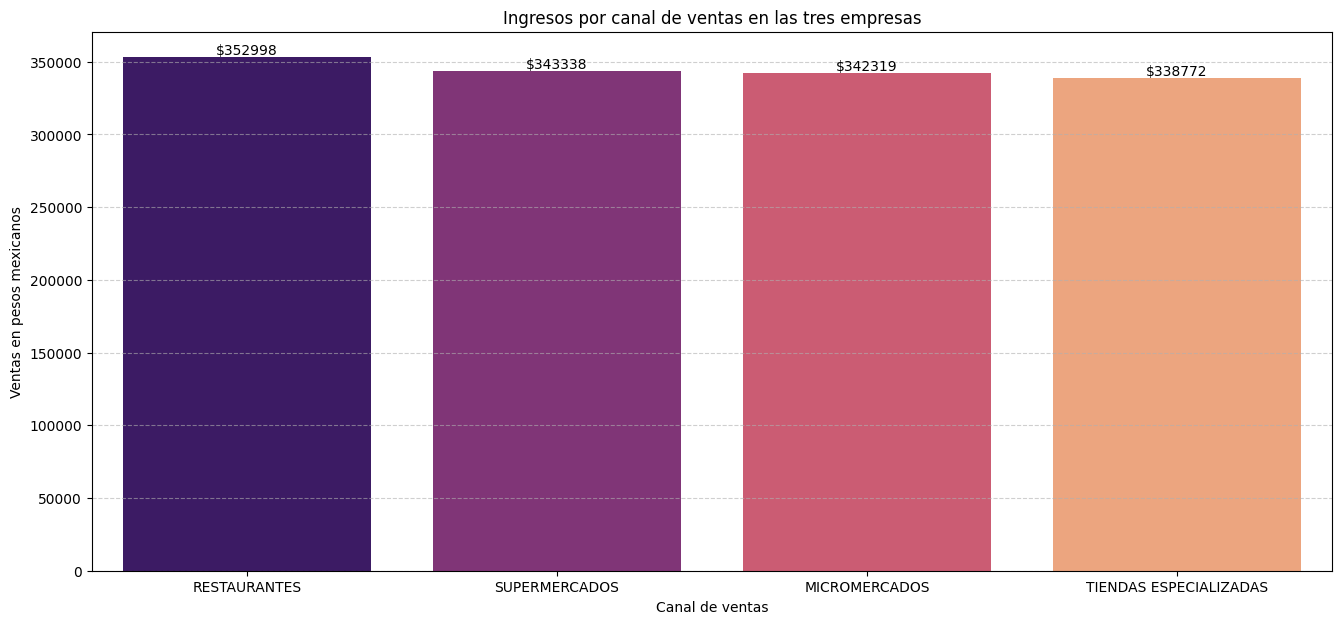

In [111]:
# Agrupamos ingresos por canal de ventas
canal_ingresos = df.groupby("CANAL")["PESO MEXICANO"].sum().sort_values(ascending=False)

# Graficamos
plt.figure(figsize=(16,7))
plt.title("Ingresos por canal de ventas en las tres empresas")
barras = sns.barplot(x=canal_ingresos.index,
                     y=canal_ingresos.values,
                     hue=canal_ingresos.index,
                     palette="magma")
for contenedores in barras.containers:
    barras.bar_label(contenedores,
                     fmt='$%.0f')
plt.xlabel("Canal de ventas")
plt.ylabel("Ventas en pesos mexicanos")
plt.grid(axis="y",
         linestyle="--",
         alpha=0.6)
plt.show()


## ¿Qué canal de ventas genera mas ingresos en la empresa "DISTRIBUIDORA CENTRAL"?

El canal de ventas que genera mas ingresos en la empresa "DISTRIBUIDORA CENTRAL" son los `restaurantes`, ya que generan `$121,764` pesos mexicanos 🇲🇽 en ventas o `$4,471,767` de bolivares venezolanos 🇻🇪

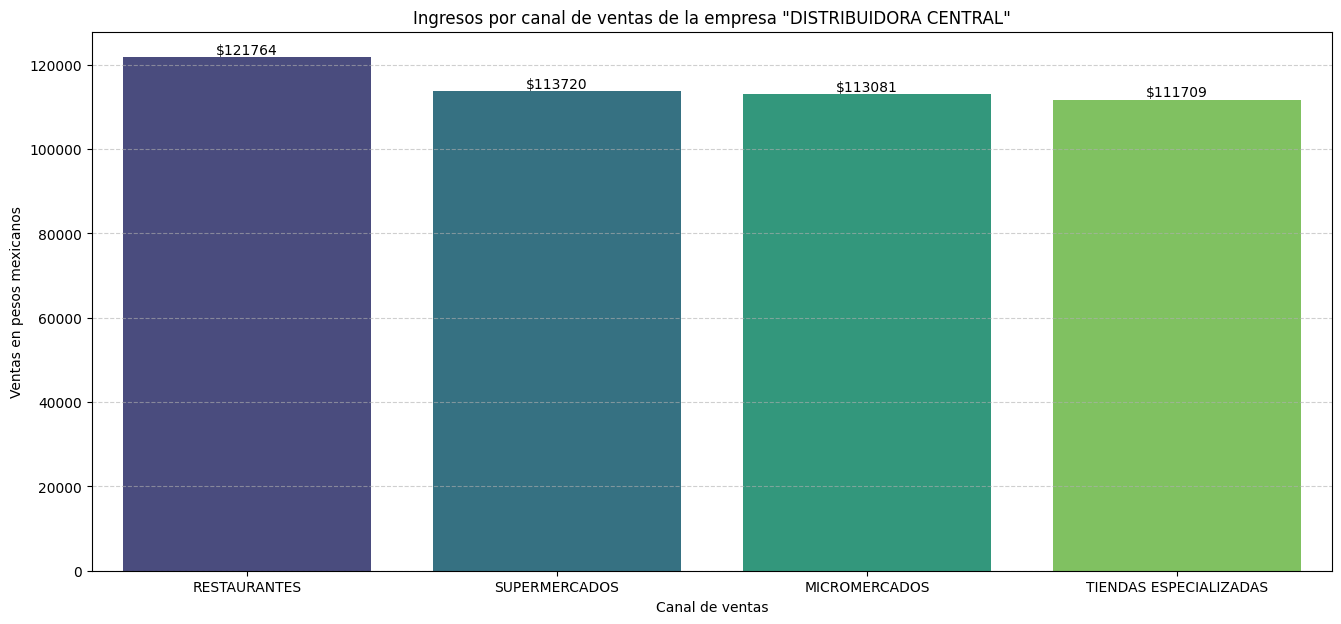

In [114]:
# Agrupamos ingresos por canal de ventas
canal_ingresos_dc = df_dist_central.groupby("CANAL")["PESO MEXICANO"].sum().sort_values(ascending=False)

# Graficamos
plt.figure(figsize=(16,7))
plt.title('Ingresos por canal de ventas de la empresa "DISTRIBUIDORA CENTRAL"')
barras = sns.barplot(x=canal_ingresos_dc.index,
                     y=canal_ingresos_dc.values,
                     hue=canal_ingresos_dc.index,
                     palette="viridis")
for contenedores in barras.containers:
    barras.bar_label(contenedores,
                     fmt='$%.0f')
plt.xlabel("Canal de ventas")
plt.ylabel("Ventas en pesos mexicanos")
plt.grid(axis="y",
         linestyle="--",
         alpha=0.6)
plt.show()

## ¿Qué canal de ventas genera mas ingresos en la empresa "AVÍCOLA DEL NORTE"?

El canal de ventas que genera mas ingresos en la empresa "AVÍCOLA DEL NORTE" son los `micromercados`, ya que generan `$115,208` pesos mexicanos 🇲🇽 en ventas o `$4,230,999` de bolivares venezolanos 🇻🇪

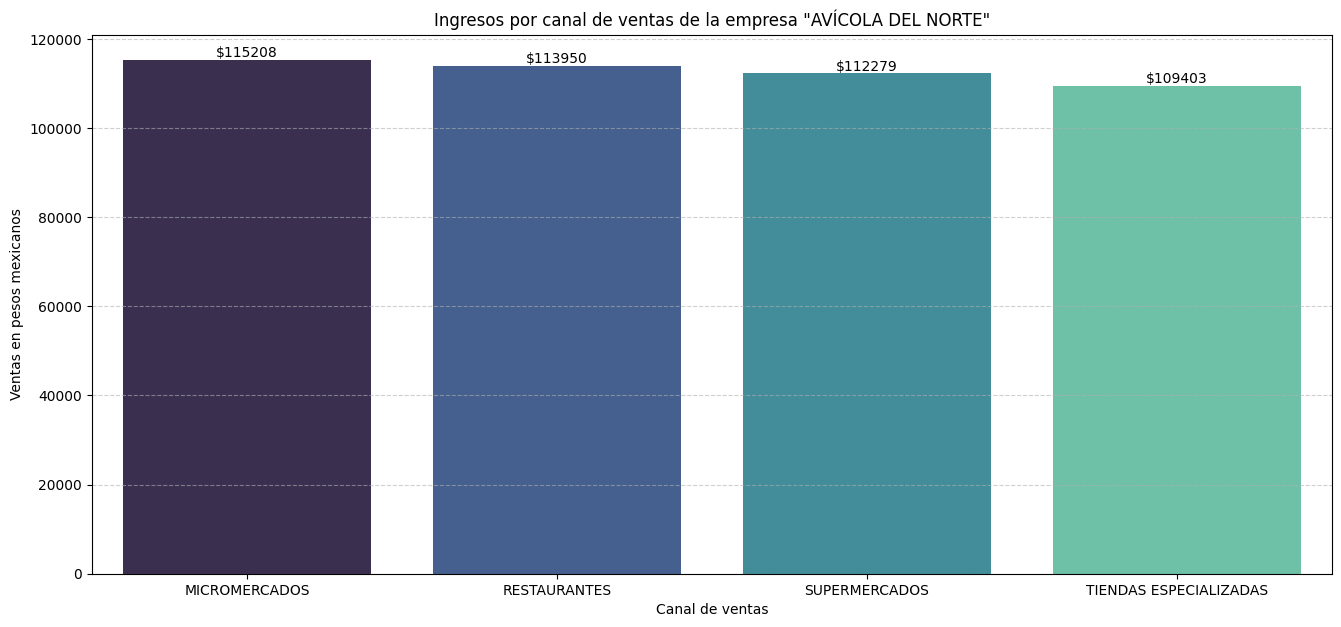

In [126]:
# Agrupamos ingresos por canal de ventas
canal_ingresos_an = df_avicola_nte.groupby("CANAL")["PESO MEXICANO"].sum().sort_values(ascending=False)

# Graficamos
plt.figure(figsize=(16,7))
plt.title('Ingresos por canal de ventas de la empresa "AVÍCOLA DEL NORTE"')
barras = sns.barplot(x=canal_ingresos_an.index,
                     y=canal_ingresos_an.values,
                     hue=canal_ingresos_an.index,
                     palette="mako")
for contenedores in barras.containers:
    barras.bar_label(contenedores,
                     fmt='$%.0f')
plt.xlabel("Canal de ventas")
plt.ylabel("Ventas en pesos mexicanos")
plt.grid(axis="y",
         linestyle="--",
         alpha=0.6)
plt.show()

## ¿Qué canal de ventas genera mas ingresos en la empresa "POLLOS ANDINOS"?

El canal de ventas que genera mas ingresos en la empresa "POLLOS ANDINOS" son las `tiendas especializadas`, ya que generan `$117,659` pesos mexicanos 🇲🇽 en ventas o `$4,321,012` de bolivares venezolanos 🇻🇪

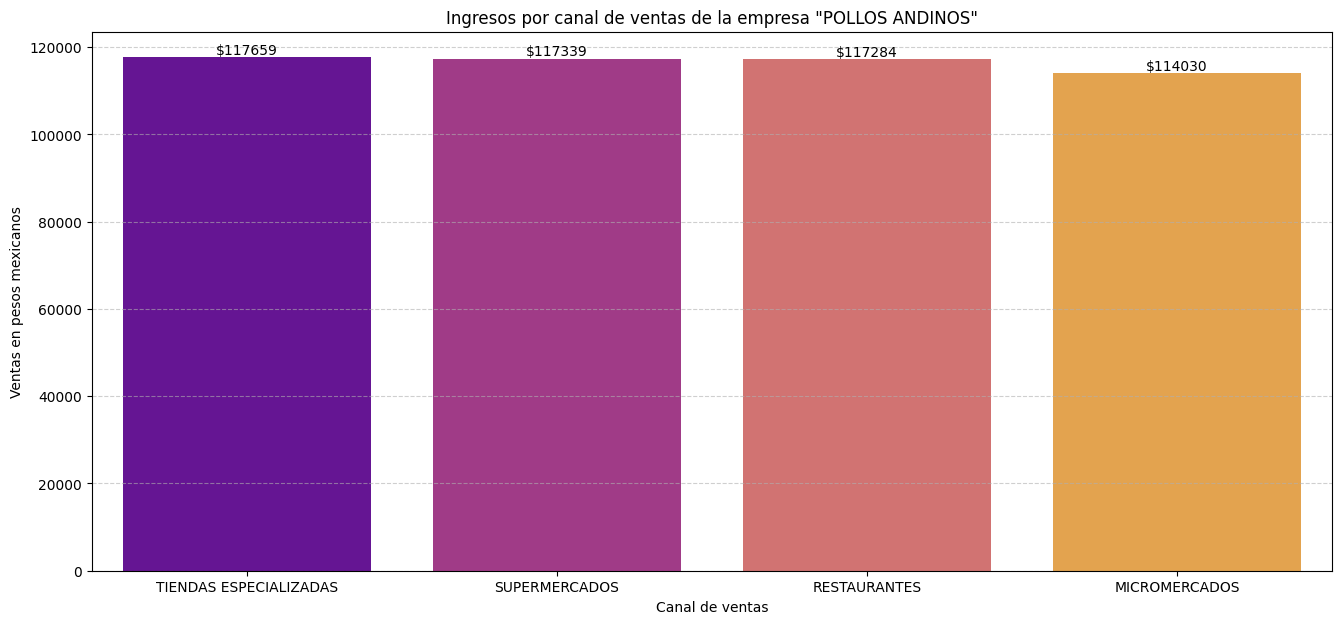

In [136]:
# Agrupamos ingresos por canal de ventas
canal_ingresos_pa = df_pollos_andinos.groupby("CANAL")["PESO MEXICANO"].sum().sort_values(ascending=False)

# Graficamos
plt.figure(figsize=(16,7))
plt.title('Ingresos por canal de ventas de la empresa "POLLOS ANDINOS"')
barras = sns.barplot(x=canal_ingresos_pa.index,
                     y=canal_ingresos_pa.values,
                     hue=canal_ingresos_pa.index,
                     palette="plasma")
for contenedores in barras.containers:
    barras.bar_label(contenedores,
                     fmt='$%.0f')
plt.xlabel("Canal de ventas")
plt.ylabel("Ventas en pesos mexicanos")
plt.grid(axis="y",
         linestyle="--",
         alpha=0.6)
plt.show()